# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage import color, io, transform
from tqdm import tqdm

In [2]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torchvision.models.resnet import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader, Dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# U-Net with ResNet backbone

In [3]:

class UNetResNet(nn.Module):
    def __init__(self, resnet, out_channels):
        super(UNetResNet, self).__init__()
        self.encoder = resnet
        self.encoder.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

        self.pool = nn.MaxPool2d(2, 2)

        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.up_conv1 = nn.Conv2d(512, 256, kernel_size=3, padding=1)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.up_conv2 = nn.Conv2d(256, 128, kernel_size=3, padding=1)

        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.up_conv3 = nn.Conv2d(128, 64, kernel_size=3, padding=1)

        # Additional convolution to ensure the output size matches the input size
        self.up4 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)  
        
        self.conv_last = nn.Conv2d(64, out_channels, kernel_size=1)
        
    def forward(self, x):
        # Encoder
        x1 = self.encoder.conv1(x)
        x1 = self.encoder.bn1(x1)
        x1 = self.encoder.relu(x1)
        x1 = self.encoder.maxpool(x1)

        x2 = self.encoder.layer1(x1)
        x3 = self.encoder.layer2(x2)
        x4 = self.encoder.layer3(x3)
        x5 = self.encoder.layer4(x4)

        # Decoder
        x = self.up1(x5)
        x = torch.cat([x, x4], dim=1)
        x = self.up_conv1(x)

        x = self.up2(x)
        x = torch.cat([x, x3], dim=1)
        x = self.up_conv2(x)

        x = self.up3(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up_conv3(x)

        # upsampling to ensure output size matches input size
        x = self.up4(x)  
        x = self.up4(x)  
        
        x = self.conv_last(x)
        return x



In [4]:
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model = UNetResNet(resnet, 2)

In [5]:
model.parameters

<bound method Module.parameters of UNetResNet(
  (encoder): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05

# Training dataset

## Loading data (test)

In [6]:
import os
os.getcwd()

'c:\\Users\\hnamt\\Documents\\Studium\\Maschinelles Lernen 2'

In [7]:
# path of images to colorize
image_path = os.path.join(os.getcwd(), "student_dataset", "train")

# image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images 
    transforms.ToTensor(),          # Convert images to PyTorch tensors
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize images
])

# load dataset
train_dataset = datasets.ImageFolder(root=image_path, transform=transform)

In [8]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

## Converting rgb to lab (old)

In [10]:
# convert train set to lab
L_images = []
AB_images = []
factor = 1/255.0
for image, _ in tqdm(train_dataset):
    lab_image = color.rgb2lab(np.array(image.permute(1,2,0)))
    L = image[0, :, :].unsqueeze(0)  # L channel
    AB = image[1:, :, :]  # AB channels
    L_images.append(L)
    AB_images.append(AB)

100%|██████████| 5656/5656 [01:30<00:00, 62.32it/s]


torch.Size([1, 224, 224])
tensor(0.0863) tensor(1.)


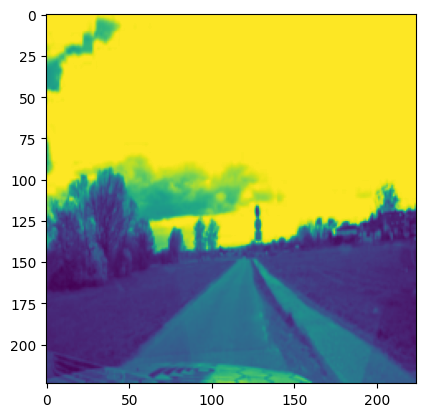

In [11]:
print(L_images[0].shape)
print(L_images[0].min(), L_images[0].max())
plt.imshow(L_images[0][0])

## Creating LAB image dataloader

In [12]:
class CustomDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_paths = [os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith(('jpg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        #image = Image.open(img_path).convert('LAB')
        image = io.imread(img_path)
        image = color.rgb2lab(image)

        if self.transform:
            image = self.transform(image)

        L = image[0, :, :].float().unsqueeze(0)  # L channel
        AB = image[1:, :, :].float()  # AB channels
                
        L = L / 50.0 - 1.0   # Normalize L channel to [-1, 1]
        AB = AB / 128.0  # Normalize AB channels to [-1, 1]
                
        return L, AB

In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224))
])

image_paths = os.path.join(os.getcwd(), "student_dataset", "train", "images")

dataset = CustomDataset(image_paths, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [20]:
L, AB = next(iter(dataloader))
print("L channel shape:", L.shape)  # Should be (1, 1, H, W)
print("AB channels shape:", AB.shape)  # Should be (1, 2, H, W)
print("L type:", type(L), L.dtype)  
print("AB type:", type(AB), AB.dtype)  

L channel shape: torch.Size([32, 1, 224, 224])
AB channels shape: torch.Size([32, 2, 224, 224])
L type: <class 'torch.Tensor'> torch.float32
AB type: <class 'torch.Tensor'> torch.float32


L type <class 'torch.Tensor'>
L shape (32, 1, 224, 224)
rgb image 15 255


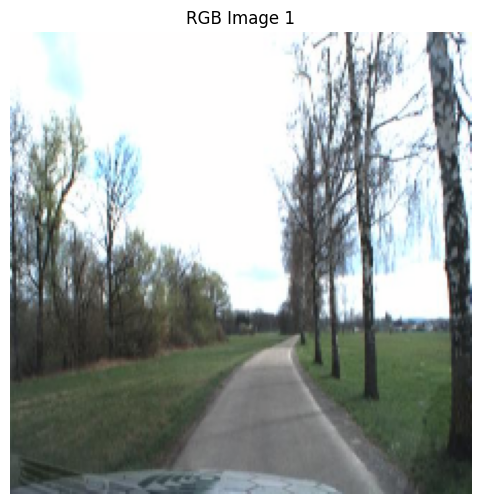

rgb image 22 255


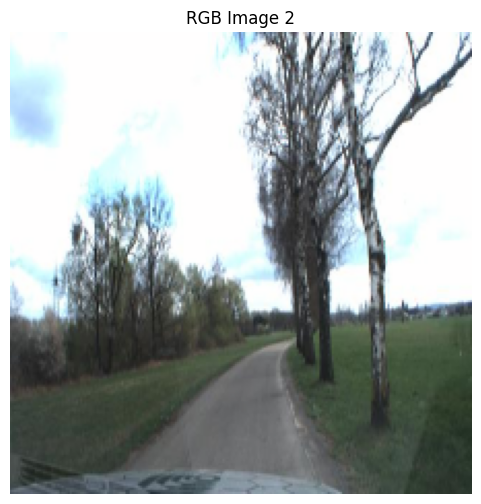

In [21]:
def visualize_rgb_batch(dataloader, num_images=5):
    """
    Visualizes a batch of RGB images from the DataLoader.
    
    Parameters:
    - dataloader: PyTorch DataLoader instance
    - num_images: Number of images to display from the batch
    """
    # Fetch a batch of data
    data_iter = iter(dataloader)
    L, AB = next(data_iter)  # Assuming the DataLoader returns (L, AB)

    print("L type", type(L))

    # Convert tensors to numpy arrays
    L = L.numpy()
    AB = AB.numpy()
    
    print("L shape", L.shape)
    
    # Prepare LAB images by concatenating L and AB channels
    num_to_show = min(num_images, L.shape[0])
    for i in range(num_to_show):
        plt.figure(figsize=(6, 6))
        
        # Revert normalization
        L_i = (L[i] + 1.0) * 50.0  # Convert L channel back to [0, 100]
        AB_i = AB[i] * 128.0  # Convert AB channels back to [-128, 127]

        # Combine L and AB channels to form LAB image
        lab_image = np.concatenate((L_i, AB_i), axis=0)  # Shape: (3, H, W)
        lab_image = np.transpose(lab_image, (1, 2, 0))  # Shape: (H, W, C)
        
        # Convert LAB to RGB
        rgb_image = np.array(color.lab2rgb(lab_image) * 255.0).astype(int)
        print("rgb image", rgb_image.min(),  rgb_image.max())
        
        # Plot the RGB image
        plt.subplot(1, 1, 1)
        plt.title(f'RGB Image {i+1}')
        plt.imshow(rgb_image)
        #plt.imshow(np.transpose(L[i], (1, 2, 0)))
        plt.axis('off')

        plt.show()

# Example usage:
# Ensure you have your dataloader ready
visualize_rgb_batch(dataloader, num_images=2)


## Training

In [22]:
# ONLY USE WHEN RETRAINING

# Initialize ResNet and UNetResNet
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model = UNetResNet(resnet, 2)

# Get the model path
model_path = os.path.join(os.getcwd(), "model_v2.pth")
print(model_path)

# Load the state dictionary
state_dict = torch.load(model_path)

# Load the state dictionary into the model
model.load_state_dict(state_dict)



c:\Users\hnamt\Documents\Studium\Maschinelles Lernen 2\model_v2.pth


<All keys matched successfully>

In [75]:
# Initialize model, loss function, and optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop
num_epochs = 7
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    # Initialize tqdm for the dataloader
    with tqdm(total=len(dataloader), desc=f'Epoch {epoch + 1}/{num_epochs}', unit='batch') as pbar:
        for i, data in enumerate(dataloader, 0):
            L, AB = data
            L, AB = L.to(device), AB.to(device)
            
            optimizer.zero_grad()
            outputs = model(L)
            loss = criterion(outputs, AB)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            pbar.set_postfix({'loss': running_loss / (i + 1)})
            pbar.update(1)  # Update progress bar

    print(f'Epoch {epoch + 1} finished. Average loss: {running_loss / len(dataloader):.4f}')

print('Finished Training')

Epoch 1/7: 100%|██████████| 177/177 [17:09<00:00,  5.81s/batch, loss=0.000322]


Epoch 1 finished. Average loss: 0.0003


Epoch 2/7: 100%|██████████| 177/177 [17:47<00:00,  6.03s/batch, loss=0.000218]


Epoch 2 finished. Average loss: 0.0002


Epoch 3/7: 100%|██████████| 177/177 [17:11<00:00,  5.83s/batch, loss=0.000205]


...

Epoch 5 finished. Average loss: 0.0002


Epoch 6/7: 100%|██████████| 177/177 [17:17<00:00,  5.86s/batch, loss=0.000182]


Epoch 6 finished. Average loss: 0.0002


Epoch 7/7: 100%|██████████| 177/177 [17:25<00:00,  5.91s/batch, loss=0.000173]

Epoch 7 finished. Average loss: 0.0002
Finished Training


## Visualization of Training Results

c:\Users\hnamt\anaconda3\envs\mlenv2\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


(3, 224, 224)
5.580181 100.0
-14.288846 3.3671627
-20.839071 15.67017
5.580181 100.0
-16.531801 7.543388
-24.049454 18.996243


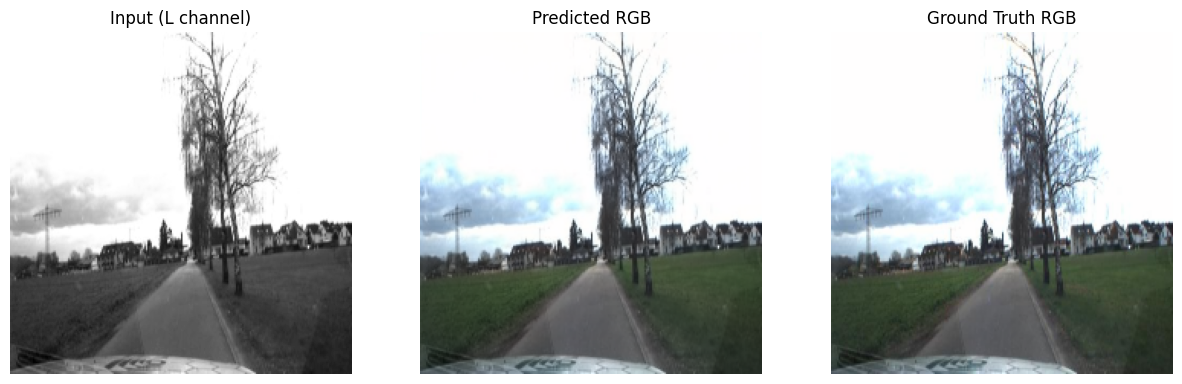

(3, 224, 224)
5.1995516 100.0
-20.728971 3.3206787
-20.520067 15.869503
5.1995516 100.0
-27.153921 13.552909
-24.78524 22.998678


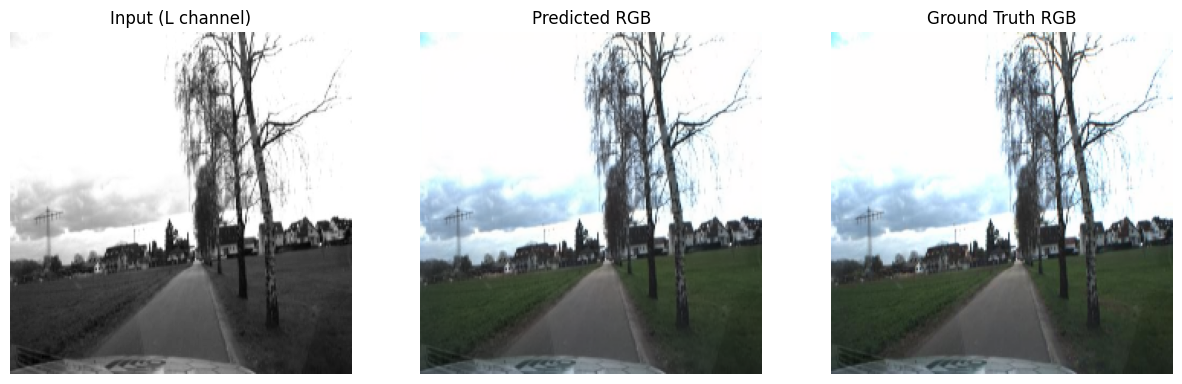

(3, 224, 224)
6.3471794 100.0
-13.457346 4.1857176
-16.711128 15.032259
6.3471794 100.0
-16.788942 12.72989
-25.252716 23.897598


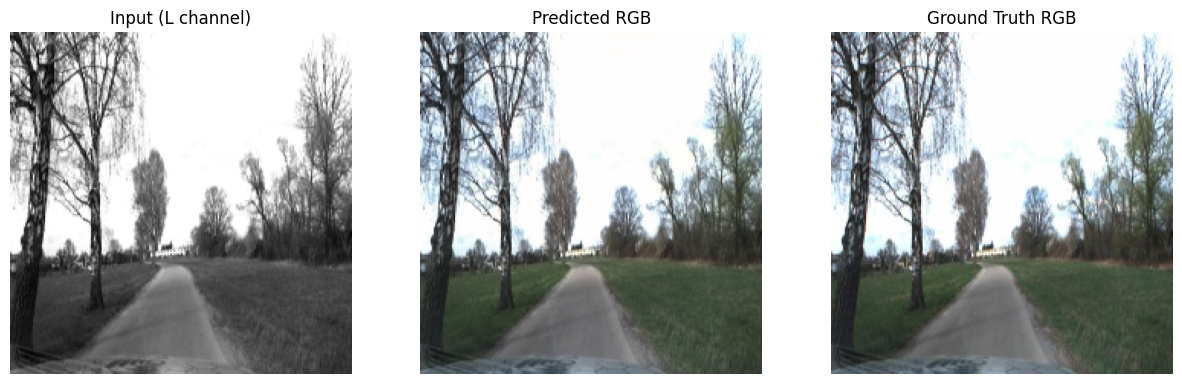

In [76]:
def lab_to_rgb(lab_image):
    # Convert LAB to RGB using OpenCV
    # OpenCV expects the LAB image in a specific range and order
    
    #ab_image = ((lab_image) * 128.0).astype(np.uint8)  # Convert to 0-255 range
    lab_image[0,:,:] = ((lab_image[0,:,:] + 1.0) * 50.0)#.astype(np.uint8)  # L
    lab_image[1:,:,:] = (lab_image[1:,:,:] * 128.0)#.astype(np.uint8)  # L
    lab_image = lab_image.transpose(1, 2, 0)  # Change to HxWxC
    print(lab_image[:,:,0].min(), lab_image[:,:,0].max())
    print(lab_image[:,:,1].min(), lab_image[:,:,1].max())
    print(lab_image[:,:,2].min(), lab_image[:,:,2].max())
    rgb_image = color.lab2rgb(lab_image)
    return rgb_image * 255.0  # Scale to [0, 1] for visualization

def visualize_results(model, dataloader, device, num_images=3):
    model.eval()  # Set the model to evaluation mode

    # Get a batch of images and labels
    with torch.no_grad():  # Disable gradient calculations
        for i, (L, AB) in enumerate(dataloader):
            if i == 0:
                L, AB = L.to(device), AB.to(device)
                outputs = model(L)

                # Convert tensors to numpy arrays for visualization
                L = L.cpu().numpy()  # Grayscale input images
                outputs = outputs.cpu().numpy()  # Model predictions
                AB = AB.cpu().numpy()  # Ground truth

                # Display some results
                num_to_show = min(num_images, L.shape[0])
                for j in range(num_to_show):
                    plt.figure(figsize=(15, 6))

                    # Plot input image (L channel)
                    plt.subplot(1, 3, 1)
                    plt.title('Input (L channel)')
                    plt.imshow(L[j, 0], cmap='gray')
                    plt.axis('off')

                    # Prepare the LAB image by concatenating L and predicted AB channels
                    lab_pred = np.concatenate([L[j], outputs[j]], axis=0)
                    print(lab_pred.shape)
                    rgb_pred = lab_to_rgb(lab_pred).astype(int)

                    # Plot model output (colorized RGB image)
                    plt.subplot(1, 3, 2)
                    plt.title('Predicted RGB')
                    plt.imshow(rgb_pred)
                    plt.axis('off')

                    # Prepare the LAB image by concatenating L and ground truth AB channels
                    lab_gt = np.concatenate([L[j], AB[j]], axis=0)
                    rgb_gt = lab_to_rgb(lab_gt).astype(int)

                    # Plot ground truth (colorized RGB image)
                    plt.subplot(1, 3, 3)
                    plt.title('Ground Truth RGB')
                    plt.imshow(rgb_gt)
                    plt.axis('off')

                    plt.show()

            # Stop after displaying the requested number of images
            if i >= num_images:
                break

# Example usage:
visualize_results(model, dataloader, device)


## Saving model

In [77]:
# Assuming 'model' is your model instance
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")

# Example usage
save_model(model, 'model_v3.pth')


Model saved to model_v3.pth


# Testing

## Load model?

In [81]:
# Initialize ResNet and UNetResNet
resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model = UNetResNet(resnet, 2)

# Get the model path
model_path = os.path.join(os.getcwd(), "model_v2.pth")
print(model_path)

# Load the state dictionary
state_dict = torch.load(model_path)

# Load the state dictionary into the model
model.load_state_dict(state_dict)

# Run model on GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Set the model to evaluation mode
model.eval()



c:\Users\hnamt\Documents\Studium\Maschinelles Lernen 2\model_v2.pth


UNetResNet(
  (encoder): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_

## Loading data

In [27]:
class TestDataset(Dataset):
    def __init__(self, image_dir, transform=None):
        self.image_dir = image_dir
        self.image_paths = [os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith(('jpg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = io.imread(img_path, as_gray=True)

        if self.transform:
            image = self.transform(image)

        gray = image.float() #.unsqueeze(0) # Values range [0.0, 1.0]
                
        gray = gray * 2.0 - 1.0#/ 127.5 - 1.0   # Normalize channel to [-1, 1]
                
        return gray

In [82]:
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224))
])

image_paths = os.path.join(os.getcwd(), "student_dataset", "test_color", "images")

testset = TestDataset(image_paths, transform=test_transform)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

## Minor data tests

In [12]:
test_path = os.path.join(os.getcwd(), "student_dataset", "test_color", "images","2_0000.jpg")
print(test_path)
img = io.imread(test_path)

#img.max()
torch.Tensor(img).float().max()

c:\Users\hnamt\Documents\Studium\Maschinelles Lernen 2\student_dataset\test_color\images\2_0000.jpg


tensor(255.)

In [14]:
gray_test = next(iter(testloader))
print("gray channel shape:", gray_test.shape)  # Should be (1, 1, H, W)
print("gray type:", type(gray_test), gray_test.dtype)  # Should be (1, 1, H, W)


c:\Users\hnamt\anaconda3\envs\mlenv2\lib\site-packages\torchvision\transforms\functional.py:1603: UserWarning: The default value of the antialias parameter of all the resizing transforms (Resize(), RandomResizedCrop(), etc.) will change from None to True in v0.17, in order to be consistent across the PIL and Tensor backends. To suppress this warning, directly pass antialias=True (recommended, future default), antialias=None (current default, which means False for Tensors and True for PIL), or antialias=False (only works on Tensors - PIL will still use antialiasing). This also applies if you are using the inference transforms from the models weights: update the call to weights.transforms(antialias=True).
  warnings.warn(


gray channel shape: torch.Size([50, 1, 256, 256])
gray type: <class 'torch.Tensor'> torch.float32


In [15]:
print("g range", gray_test[0].min(), gray_test[0].max())


g range tensor(-0.8123) tensor(1.)


In [17]:
#plt.hist(gray_test[0][0])

## Prediction of Test Images and Visualization

1it [00:00,  1.02it/s]


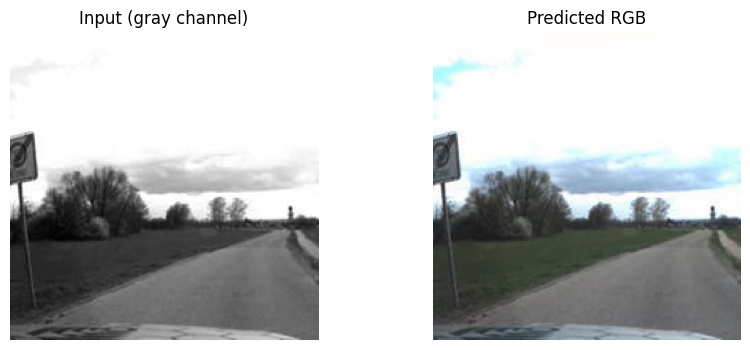

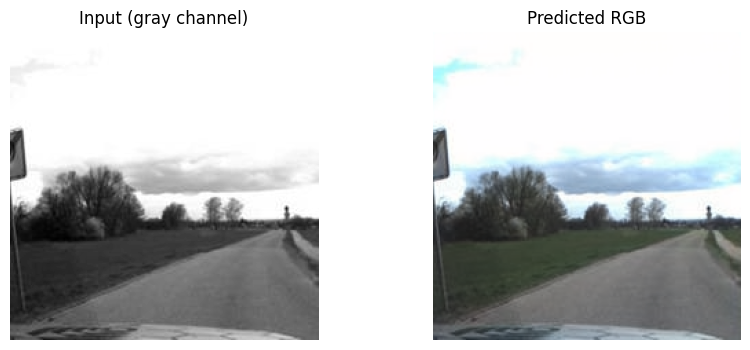

In [79]:
model.eval()  # Set the model to evaluation mode

num_images = 2

# Get a batch of images and labels
with torch.no_grad():  # Disable gradient calculations
    for i, gray in tqdm(enumerate(testloader)):
        #print("g range", gray[0].min(), gray[0].max())
        if i == 0:
            gray = gray.to(device)
            outputs = model(gray)

            # Convert tensors to numpy arrays for visualization
            gray = gray.cpu().numpy()  # Grayscale input images
            outputs = outputs.cpu().numpy()  # Model predictions
            
            #print("gray shape", gray.shape)

            # Display some results
            num_to_show = min(num_images, gray.shape[0])
            for j in range(num_to_show):
                plt.figure(figsize=(10, 4))

                # Plot input image (L channel)
                plt.subplot(1, 2, 1)
                plt.title('Input (gray channel)')
                plt.imshow(gray[j, 0], cmap='gray')
                plt.axis('off')

                # Prepare the LAB image by concatenating L and predicted AB channels
                #print("g range", gray[j].min(), gray[j].max())
                #print("ab range", outputs[j].min(), outputs[j].max())

                gray_denorm = (gray[j] + 1.0) * 50.0
                AB_denorm = outputs[j] * 128.0
                #print("g range", gray_norm.min(), gray_norm.max())
                #print("ab range", AB_norm.min(), AB_norm.max())
                #print("g pred", gray_norm.shape)
                #print("ab pred", AB_norm.shape)
                lab_pred = np.concatenate([gray_denorm, AB_denorm], axis=0)
                lab_pred = lab_pred.transpose(1, 2, 0)  # Change to HxWxC
                #print("lab pred", lab_pred.shape)
                rgb_pred = color.lab2rgb(lab_pred) * 255.0
                rgb_pred = rgb_pred.astype(int)

                # Plot model output (colorized RGB image)
                plt.subplot(1, 2, 2)
                plt.title('Predicted RGB')
                plt.imshow(rgb_pred)
                plt.axis('off')

        # Stop after displaying the requested number of images
        if i >= num_images:
            break



## Save results

In [83]:
# Set the model to evaluation mode
model.eval()

# Initialize a list to store the results
#results = []
img_shape = 224
results = np.zeros((50,img_shape,img_shape,3))

# Get a batch of images and labels
with torch.no_grad():  # Disable gradient calculations
    for i, gray in tqdm(enumerate(testloader)):
        gray = gray.to(device)
        outputs = model(gray)

        # Convert tensors to numpy arrays for saving
        gray = gray.cpu().numpy()  # Grayscale input images
        outputs = outputs.cpu().numpy()  # Model predictions
        
        # Denormalize LAB values
        gray_denorm = (gray + 1.0) * 50.0
        AB_denorm = outputs * 128.0

        # Convert LAB to RGB
        lab_pred = np.concatenate([gray_denorm, AB_denorm], axis=1)
        print("lab pred shape", lab_pred.shape)
        
        for j in range(lab_pred.shape[0]):
            rgb_pred = color.lab2rgb(lab_pred[j].transpose(1,2,0)) * 255.0
            #rgb_pred = transform.resize(rgb_pred, (img_shape,img_shape,3)).astype(int)
            rgb_pred = rgb_pred.astype(int)
            #print("rgb pred shape", rgb_pred.shape)
            
            # Save the results
            #results.append(rgb_pred)
            results[j] = rgb_pred
            
        #print(len(results))
        
#results_np = np.array(results)
print("results shape",results.shape)

# Save the results to a file for later use
np.save('results_224_573MSE.npy', results)


0it [00:00, ?it/s]

lab pred shape (50, 3, 224, 224)


1it [00:01,  1.42s/it]

results shape (50, 224, 224, 3)


## Visualize random predicted colorized image

In [31]:
# Function to randomly display an image from the array
def show_random_image(images):
    index = np.random.randint(0, images.shape[0] - 1)  # Select a random index
    image = images[index]
    
    plt.figure(figsize=(6, 6))
    plt.title(f'Random Image {index}')
    plt.imshow(image)
    plt.axis('off')
    plt.show()

In [32]:
# Assume images_array is the loaded (50, 256, 256, 3) array
images_array = np.load('results_224_v2.npy').astype(int)  # Replace 'results.npy' with your actual file name

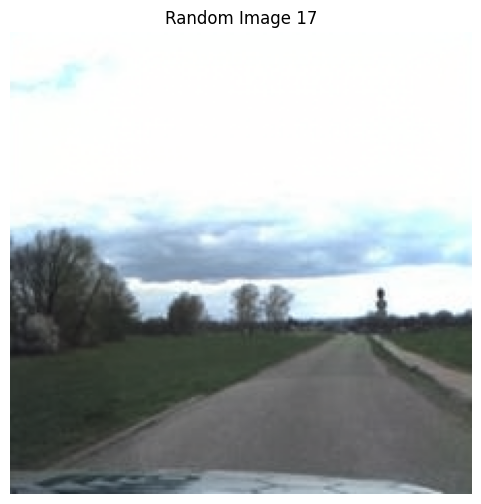

In [74]:
# Show a random image
show_random_image(images_array)